<a id="introducao"></a>
# Introdução

A análise busca entender quais públicos e anúncios apresentam os melhores resultados, transformando os dados das campanhas em informações úteis para apoiar decisões de marketing.  
O projeto será dividido em duas áreas principais:

- **Faixa etária:** identificar quais grupos de idade apresentam mais cliques, adições ao carrinho e maior intenção de compra.
- **Desempenho dos anúncios:** comparar os anúncios para entender quais geram mais cliques, adições ao carrinho, compras e melhores resultados em relação ao valor investido.

Além dos valores absolutos, serão analisadas métricas como **CTR do link, CPC do link, taxa de adição ao carrinho, custo por compra e ROAS**, sempre que esses dados estiverem disponíveis no conjunto de dados.

### Perguntas de negócio

A análise busca responder às seguintes perguntas:

1. Qual faixa etária mais clicou nos anúncios?
2. Qual faixa etária mais adicionou produtos ao carrinho?
3. Qual faixa etária apresenta a maior taxa de adição ao carrinho?
4. Qual anúncio recebeu mais cliques?
5. Qual anúncio gerou mais adições ao carrinho?
6. Qual anúncio apresentou a melhor taxa de adição ao carrinho?
7. Qual anúncio apresentou o melhor desempenho geral considerando engajamento, conversões e custos?

Ao final do projeto, serão apresentados os principais resultados e recomendações que possam auxiliar na definição do público-alvo, na distribuição do orçamento e na escolha dos anúncios com melhor desempenho.

# Sumário

1. [Introdução](#introducao)  
2. [Carregamento e Visão Geral dos Dados](#carregamento-dados)  
3. [Preparação dos Dados](#preparacao-dados)  
4. [Análise do Público](#analise-publico)
5. [Análise do Desempenho dos Anúncios](#desempenho-anuncios)  
6. [Principais Resultados](#principais-resultados)  
7. [Recomendações para a Loja](#recomendacoes)  
8. [Conclusão](#conclusao)

<a id="carregamento-dados"></a>
# 2. Carregamento e Visão Geral dos Dados

Nesta etapa, o conjunto de dados exportado do Meta Ads será carregado e inspecionado para compreender sua estrutura, dimensões e principais características.

Serão analisados os tipos de dados, valores ausentes, possíveis registros duplicados e as categorias presentes nas principais variáveis antes de iniciar a preparação e transformação dos dados.

In [214]:
# Importar as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [215]:
# Carregar o conjunto de dados
pickhub_df = pd.read_excel('/content/Relatório-sem-título-set-20-2026-a-out-3-2026.xlsx')

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [216]:
# Visualizar as primeiras cinco linhas do DataFrame
pickhub_df.head()

,Nome da campanha,Nome do conjunto de anúncios,Nome da conta,Nome do anúncio,Idade,Gênero,Anúncios,Veiculação do anúncio,Alcance,Impressões,...,Valor gasto (CHF),Início,Término,Compras,Custo por compra,Cliques no link,CPM (custo por 1.000 impressões),Adições ao carrinho,Início dos relatórios,Encerramento dos relatórios
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16064,24629,...,367.460000,NaN,NaN,8.0,45.932500,766.0,14.919810,59.0,2026-09-20,2026-10-03
1,Retinal Celimax | Novos Criativos | CH | 23.09...,CH | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 1 | Power of Retinal,35-44,female,Retinal Celimax | Vídeo 1 | Power of Retinal,active,3233,4439,...,57.156541,2026-09-23,Ongoing,1.0,57.156541,80.0,12.875995,15.0,2026-09-20,2026-10-03
2,Retinal Celimax | Novos Criativos | CH | 23.09...,CH | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 1 | Power of Retinal,45-54,female,Retinal Celimax | Vídeo 1 | Power of Retinal,active,2243,2951,...,45.387253,2026-09-23,Ongoing,3.0,15.129084,63.0,15.380296,8.0,2026-09-20,2026-10-03
3,Retinal Celimax | Vídeos | CH | 19.09.2026,CH | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 2 | Dark Spot Care,35-44,female,Retinal Celimax | Vídeo 2 | Dark Spot Care,not_delivering,1200,1388,...,26.090000,2026-09-19,Ongoing,NaN,NaN,43.0,18.796830,2.0,2026-09-20,2026-10-03
4,Retinal Celimax | Novos Criativos | CH | 23.09...,CH | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 1 | Power of Retinal,55-64,female,Retinal Celimax | Vídeo 1 | Power of Retinal,active,750,965,...,21.528697,2026-09-23,Ongoing,2.0,10.764348,50.0,22.309531,4.0,2026-09-20,2026-10-03


In [217]:
# Visualizar as informações do DataFrame
pickhub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Nome da campanha                  227 non-null    object 
 1   Nome do conjunto de anúncios      227 non-null    object 
 2   Nome da conta                     227 non-null    object 
 3   Nome do anúncio                   227 non-null    object 
 4   Idade                             227 non-null    object 
 5   Gênero                            227 non-null    object 
 6   Anúncios                          227 non-null    object 
 7   Veiculação do anúncio             227 non-null    object 
 8   Alcance                           228 non-null    int64  
 9   Impressões                        228 non-null    int64  
 10  Cliques (todos)                   228 non-null    int64  
 11  Moeda                             228 non-null    object 
 12  CPC (tod

### Visão geral inicial

O conjunto de dados contém **228 linhas e 23 colunas**.

As colunas incluem informações sobre campanhas, conjuntos de anúncios, anúncios,
faixa etária e gênero, além de métricas de desempenho como alcance, impressões,
cliques, gastos, compras e adições ao carrinho.

Durante a inspeção inicial, foi observado que algumas colunas descritivas possuem
227 valores preenchidos, enquanto as principais métricas possuem 228 registros.
Isso pode indicar a presença de uma linha adicional de resumo ou total do relatório,
que será verificada antes da preparação dos dados.

In [218]:
# Visualizar as últimas cinco linhas do DataFrame
pickhub_df.tail()

,Nome da campanha,Nome do conjunto de anúncios,Nome da conta,Nome do anúncio,Idade,Gênero,Anúncios,Veiculação do anúncio,Alcance,Impressões,...,Valor gasto (CHF),Início,Término,Compras,Custo por compra,Cliques no link,CPM (custo por 1.000 impressões),Adições ao carrinho,Início dos relatórios,Encerramento dos relatórios
223,Arencia Skincare | Vídeos | CH | 21.09.2026,CH | Arencia Skincare | Compras | Amplo,PickHub's ad account,Arencia | Vídeo 1 | K-Beauty,55-64,male,Arencia | Vídeo 1 | K-Beauty,not_delivering,1,1,...,0.0,2026-09-21,Ongoing,NaN,NaN,1.0,0.0,NaN,2026-09-20,2026-10-03
224,Retinal Celimax | Novos Criativos | DE | 29.09...,DE | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 2 | Dark Spot Care,55-64,unknown,Retinal Celimax | Vídeo 2 | Dark Spot Care,active,1,1,...,0.0,2026-09-29,Ongoing,NaN,NaN,NaN,0.0,NaN,2026-09-20,2026-10-03
225,Retinal Celimax | Novos Criativos | CH | 27.09...,CH | Retinal Celimax | Compras | Initiete Chec...,PickHub's ad account,Retinal Celimax | Vídeo 1 | Power of Retinal,55-64,unknown,Retinal Celimax | Vídeo 1 | Power of Retinal,not_delivering,1,1,...,0.0,2026-09-27,Ongoing,NaN,NaN,NaN,0.0,NaN,2026-09-20,2026-10-03
226,Retinal Celimax | Pagina Beauty| CH | 03.10.2026,CH | Retinal Celimax | Compras | Amplo,PickHub's ad account,Retinal Celimax | Vídeo 2 | Dark Spot Care,65+,female,Retinal Celimax | Vídeo 2 | Dark Spot Care,not_delivering,1,1,...,0.0,2026-10-03,Ongoing,NaN,NaN,NaN,0.0,NaN,2026-09-20,2026-10-03
227,Retinal Celimax | Novos Criativos | CH | 27.09...,CH | Retinal Celimax | Compras | Initiete Chec...,PickHub's ad account,Retinal Celimax | Vídeo 1 | Power of Retinal,65+,unknown,Retinal Celimax | Vídeo 1 | Power of Retinal,not_delivering,1,1,...,0.0,2026-09-27,Ongoing,NaN,NaN,NaN,0.0,NaN,2026-09-20,2026-10-03


In [219]:
# Remover a linha de resumo do relatório do Meta Ads
pickhub_df = pickhub_df[pickhub_df['Nome da campanha'].notna()].copy()

# Redefinir o índice
pickhub_df.reset_index(drop=True, inplace=True)

pickhub_df.shape

(227, 23)

In [220]:
pickhub_df['Nome da campanha'].isna().sum()

np.int64(0)

### Linha de resumo

Durante a inspeção dos dados, foi identificada uma linha de resumo gerada pelo
Meta Ads. Essa linha não representava uma campanha, conjunto de anúncios ou
anúncio específico, mas continha os valores totais do relatório.

Como esses valores já estão presentes nas demais linhas do conjunto de dados,
a linha de resumo foi removida para evitar duplicação das métricas durante as
agregações e análises posteriores.

In [221]:
# Exibir as faixas etárias únicas
pickhub_df['Idade'].unique()

array(['35-44', '45-54', '55-64', '25-34', '65+', '18-24'], dtype=object)

In [222]:
# Exibir as categorias de gênero únicas
pickhub_df['Gênero'].unique()

array(['female', 'male', 'unknown'], dtype=object)

In [223]:
# Contar a quantidade de anúncios únicos
pickhub_df['Nome do anúncio'].nunique()

6

In [224]:
# Verificar se existem linhas duplicadas
pickhub_df.duplicated().sum()

np.int64(0)

<a id="preparacao-dados"></a>

# 3. Preparação dos Dados

Nesta etapa, os dados serão preparados para a análise. Serão realizados ajustes nos tipos de dados, tratamento de valores ausentes e criação de novas métricas necessárias para comparar o desempenho dos públicos e anúncios.

### Conversão dos tipos de dados

Durante a inspeção inicial, foi identificado que as colunas relacionadas a datas estavam armazenadas como texto (`object`).

Para garantir o tratamento correto dessas informações, essas colunas serão convertidas para o formato `datetime`.

A coluna `Término` contém o valor `Ongoing` em campanhas que ainda não possuem uma data de encerramento definida. Durante a conversão, esses valores serão transformados em `NaT`.

In [225]:
# Definir as colunas que contêm datas
colunas_data = [
    'Início',
    'Término',
    'Início dos relatórios',
    'Encerramento dos relatórios'
]

# Converter as colunas de data para o tipo datetime
for coluna in colunas_data:
  pickhub_df[coluna] = pd.to_datetime(pickhub_df[coluna], errors = 'coerce')


In [226]:
# Verificar os tipos de dados após a conversão
pickhub_df[colunas_data].dtypes

,0
Início,datetime64[ns]
Término,datetime64[ns]
Início dos relatórios,datetime64[ns]
Encerramento dos relatórios,datetime64[ns]


In [227]:
# Verificar valores ausentes nas colunas de data
pickhub_df[colunas_data].isna().sum()

,0
Início,0
Término,227
Início dos relatórios,0
Encerramento dos relatórios,0


### Tratamento da coluna `Término`

Após a conversão das colunas de data, foi identificado que todos os registros da coluna `Término` foram convertidos para `NaT`.

Isso ocorre porque os anúncios estavam registrados como `Ongoing` no relatório original, indicando que não havia uma data de encerramento definida no momento da exportação dos dados.

Dessa forma, os valores ausentes nessa coluna não representam um problema de qualidade dos dados, mas sim campanhas ou anúncios ainda em andamento.

### Análise dos valores ausentes

Durante a inspeção inicial, foram identificados valores ausentes em algumas métricas de desempenho, principalmente nas colunas relacionadas a cliques, adições ao carrinho, compras e custo por compra.

Antes de realizar qualquer substituição, esses valores serão analisados para entender se representam ausência de informação ou simplesmente a inexistência daquela ação no período analisado.

In [228]:
# Verificar a distribuição dos valores de compras
pickhub_df['Compras'].value_counts(dropna=False)

,count
Compras,
NaN,222
1.0,3
3.0,1
2.0,1


In [229]:
# Verificar a distribuição dos valores de cliques no link
pickhub_df['Cliques no link'].value_counts(dropna=False)

,count
Cliques no link,
NaN,143
1.0,20
2.0,12
3.0,11
5.0,5
6.0,5
9.0,3
4.0,3
11.0,2


In [230]:
# Verificar a distribuição dos valores de adições ao carrinho
pickhub_df['Adições ao carrinho'].value_counts(dropna=False)

,count
Adições ao carrinho,
NaN,206
1.0,8
2.0,7
4.0,2
3.0,2
8.0,1
15.0,1


In [231]:
# Verificar a distribuição do custo por compra
pickhub_df['Custo por compra'].value_counts(dropna=False)

,count
Custo por compra,
NaN,222
57.156541,1
15.129084,1
10.764348,1
15.800000,1
3.429792,1


### Tratamento dos valores ausentes

A análise das métricas mostrou que os valores ausentes em `Compras`, `Cliques no link` e `Adições ao carrinho` representam situações em que nenhuma dessas ações foi registrada.

Os valores preenchidos correspondem aos totais apresentados pelo Meta Ads, indicando que os valores ausentes nessas métricas podem ser substituídos por zero sem alterar os resultados do relatório.

A coluna `Custo por compra`, por outro lado, apresenta valores apenas nos registros em que houve pelo menos uma compra. Por esse motivo, seus valores ausentes serão mantidos, já que não existe custo por compra quando nenhuma compra foi realizada.

In [232]:
# Definir as métricas em que valores ausentes representam ausência de ações
colunas_acoes = [
    'Compras',
    'Cliques no link',
    'Adições ao carrinho'
]

# Substituir os valores ausentes por zero
pickhub_df[colunas_acoes] = pickhub_df[colunas_acoes].fillna(0)

# Converter as métricas de ações para números inteiros
pickhub_df[colunas_acoes] = pickhub_df[colunas_acoes].astype(int)

In [233]:
# Verificar os valores ausentes após o tratamento
pickhub_df[colunas_acoes].isna().sum()

,0
Compras,0
Cliques no link,0
Adições ao carrinho,0


In [234]:
# Verificar os tipos de dados após o tratamento
pickhub_df[colunas_acoes].dtypes

,0
Compras,int64
Cliques no link,int64
Adições ao carrinho,int64


In [235]:
# Verificar os valores ausentes restantes no conjunto de dados
pickhub_df.isna().sum()

,0
Nome da campanha,0
Nome do conjunto de anúncios,0
Nome da conta,0
Nome do anúncio,0
Idade,0
Gênero,0
Anúncios,0
Veiculação do anúncio,0
Alcance,0
Impressões,0


### Conclusão do tratamento de valores ausentes

Após o tratamento, os valores ausentes restantes estão concentrados em duas colunas:

- `Término`: todos os registros estão ausentes porque os anúncios estavam marcados como `Ongoing` no momento da exportação.
- `Custo por compra`: os valores ausentes correspondem aos registros em que nenhuma compra foi realizada.

Como esses valores ausentes possuem uma justificativa relacionada à própria estrutura dos dados, eles serão mantidos sem substituição.

In [236]:
# Calcular a taxa de cliques no link
pickhub_df['CTR do link (%)'] = (
    pickhub_df['Cliques no link'] /
    pickhub_df['Impressões'] * 100
)

In [237]:
# Calcular a taxa de adição ao carrinho apenas quando houve cliques no link
pickhub_df['Taxa de adição ao carrinho (%)'] = np.where(
    pickhub_df['Cliques no link'] > 0,
    pickhub_df['Adições ao carrinho'] /
    pickhub_df['Cliques no link'] * 100,
    np.nan
)

In [238]:
# Calcular o custo por adição ao carrinho apenas quando houve adições
pickhub_df['Custo por adição ao carrinho (CHF)'] = np.where(
    pickhub_df['Adições ao carrinho'] > 0,
    pickhub_df['Valor gasto (CHF)'] / pickhub_df['Adições ao carrinho'],
    np.nan
)

In [239]:
# Verificar se ainda existem valores infinitos
np.isinf(
    pickhub_df[
        [
            'CTR do link (%)',
            'Taxa de adição ao carrinho (%)',
            'Custo por adição ao carrinho (CHF)'
        ]
    ]
).sum()

,0
CTR do link (%),0
Taxa de adição ao carrinho (%),0
Custo por adição ao carrinho (CHF),0


In [240]:
# Verificar os valores ausentes nas novas métricas
pickhub_df[
    [
        'CTR do link (%)',
        'Taxa de adição ao carrinho (%)',
        'Custo por adição ao carrinho (CHF)'
    ]
].isna().sum()

,0
CTR do link (%),0
Taxa de adição ao carrinho (%),143
Custo por adição ao carrinho (CHF),206


### Conclusão da preparação dos dados

Após a preparação, os dados estão prontos para a etapa de análise.

As colunas de data foram convertidas para o formato adequado, os valores ausentes das métricas de ações foram tratados e novas métricas de desempenho foram criadas.

Os valores ausentes restantes nas métricas calculadas foram mantidos quando não era possível realizar o cálculo:

- A `Taxa de adição ao carrinho (%)` permanece ausente quando não houve cliques no link.
- O `Custo por adição ao carrinho (CHF)` permanece ausente quando não houve adições ao carrinho.

Dessa forma, evita-se interpretar como zero uma métrica que, na realidade, não pôde ser calculada.

<a id="analise-publico"></a>

# 4. Análise do Público

Nesta etapa, será analisado o desempenho dos anúncios entre as diferentes faixas etárias.

O objetivo é identificar quais grupos geraram mais cliques no link, mais adições ao carrinho e mais compras, além de comparar a eficiência de cada faixa etária através de métricas como CTR e taxa de adição ao carrinho.

In [241]:
# Agrupar as principais métricas por faixa etária
idade_df = (
    pickhub_df
    .groupby('Idade', as_index=False)
    .agg({
        'Impressões': 'sum',
        'Cliques no link': 'sum',
        'Adições ao carrinho': 'sum',
        'Compras': 'sum',
        'Valor gasto (CHF)': 'sum'
    })
)

idade_df

,Idade,Impressões,Cliques no link,Adições ao carrinho,Compras,Valor gasto (CHF)
0,18-24,1147,21,0,0,10.849815
1,25-34,4692,100,10,1,58.718656
2,35-44,9961,228,25,1,137.686223
3,45-54,5973,176,13,4,97.927030
4,55-64,2077,138,8,2,46.028601
5,65+,779,103,3,0,16.249674


In [242]:
# Calcular o CTR do link por faixa etária
idade_df['CTR do link (%)'] = (
    idade_df['Cliques no link'] /
    idade_df['Impressões'] * 100
)

# Calcular a taxa de adição ao carrinho por faixa etária
idade_df['Taxa de adição ao carrinho (%)'] = (
    idade_df['Adições ao carrinho'] /
    idade_df['Cliques no link'] * 100
)

# Calcular o custo por adição ao carrinho por faixa etária
idade_df['Custo por adição ao carrinho (CHF)'] = np.where(
    idade_df['Adições ao carrinho'] > 0,
    idade_df['Valor gasto (CHF)'] / idade_df['Adições ao carrinho'],
    np.nan
)

In [243]:
# Definir a ordem das faixas etárias

ordem_idade = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
]

# Ordenar o DataFrame pelas faixas etárias

idade_df['Idade'] = pd.Categorical(
    idade_df['Idade'],
    categories=ordem_idade,
    ordered=True
)

idade_df = idade_df.sort_values('Idade').reset_index(drop=True)

idade_df

,Idade,Impressões,Cliques no link,Adições ao carrinho,Compras,Valor gasto (CHF),CTR do link (%),Taxa de adição ao carrinho (%),Custo por adição ao carrinho (CHF)
0,18-24,1147,21,0,0,10.849815,1.830863,0.000000,NaN
1,25-34,4692,100,10,1,58.718656,2.131287,10.000000,5.871866
2,35-44,9961,228,25,1,137.686223,2.288927,10.964912,5.507449
3,45-54,5973,176,13,4,97.927030,2.946593,7.386364,7.532848
4,55-64,2077,138,8,2,46.028601,6.644198,5.797101,5.753575
5,65+,779,103,3,0,16.249674,13.222080,2.912621,5.416558


### Cliques no link por faixa etária

Para identificar quais grupos demonstraram maior interesse inicial nos anúncios, será analisado o número total de cliques no link por faixa etária.

Essa métrica permite observar quais públicos geraram maior volume de tráfego para a loja.

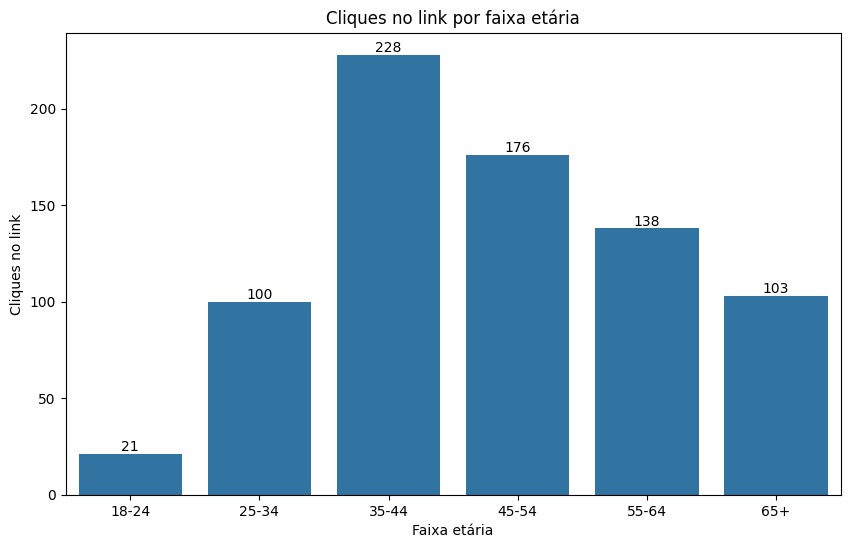

In [244]:
# Criar gráfico de cliques no link por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='Cliques no link'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Cliques no link por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Cliques no link')

plt.show()

### Insight

A faixa etária de **35–44 anos** apresentou o maior número de cliques no link, com **228 cliques**, seguida pelos grupos de **45–54 anos**, com **176 cliques**, e **55–64 anos**, com **138 cliques**.

Isso indica que as faixas de **35–44 anos** e **45–54 anos** apresentaram os maiores volumes individuais de tráfego para a loja durante o período analisado.

### Adições ao carrinho por faixa etária

Após analisar o volume de cliques, o próximo passo é identificar quais faixas etárias demonstraram maior intenção de compra.

Para isso, será analisado o número total de adições ao carrinho gerado por cada grupo.

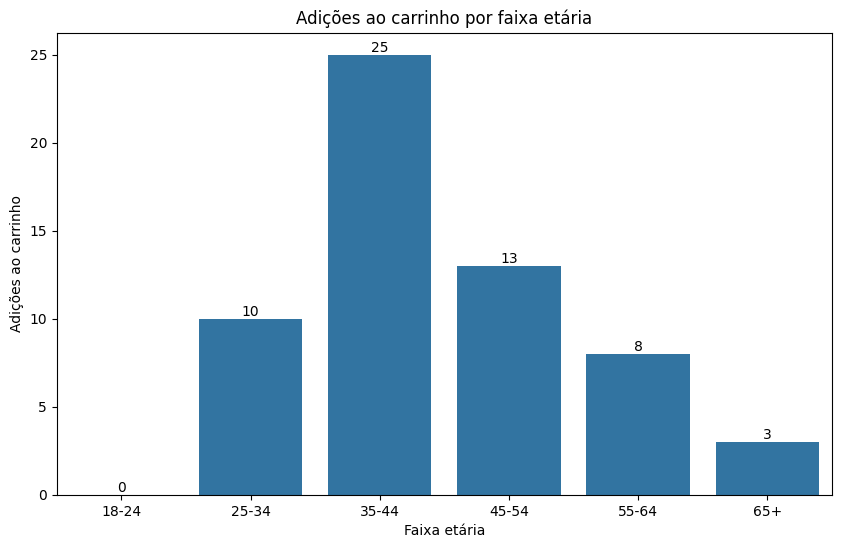

In [245]:
# Criar gráfico de adições ao carrinho por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='Adições ao carrinho'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Adições ao carrinho por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Adições ao carrinho')

plt.show()

### Insight

A faixa etária de **35–44 anos** apresentou o maior número de adições ao carrinho, com **25 eventos**, seguida pela faixa de **45–54 anos**, com **13**, e pela faixa de **25–34 anos**, com **10**.

O grupo de **35–44 anos** se destacou tanto no volume de cliques quanto nas adições ao carrinho, indicando forte interesse nos produtos anunciados.

### Taxa de adição ao carrinho por faixa etária

Além do número total de adições ao carrinho, é importante analisar a proporção de cliques que resultaram em uma adição ao carrinho.

Essa métrica permite comparar a eficiência de cada faixa etária na transformação do interesse inicial em intenção de compra.

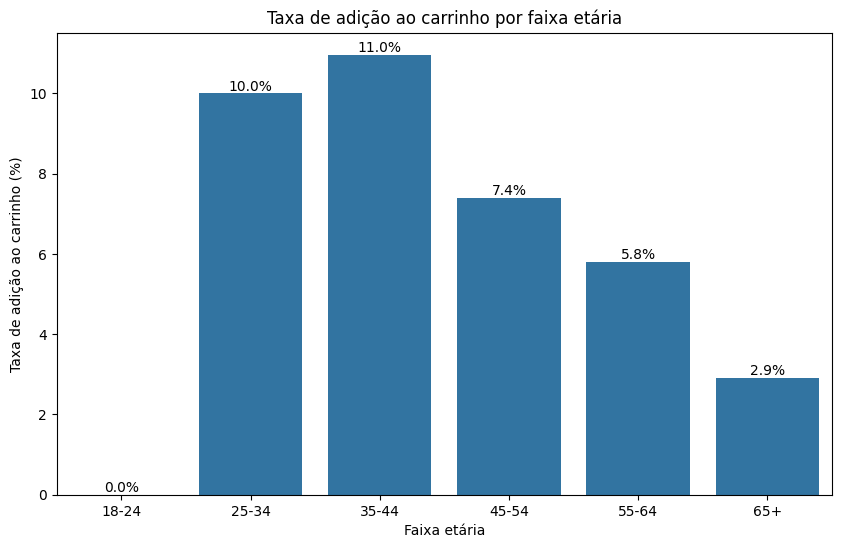

In [246]:
# Criar gráfico da taxa de adição ao carrinho por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='Taxa de adição ao carrinho (%)'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Taxa de adição ao carrinho por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Taxa de adição ao carrinho (%)')

plt.show()

### Insight

A faixa etária de **35–44 anos** apresentou a maior taxa de adição ao carrinho, com aproximadamente **11,0%**, seguida pela faixa de **25–34 anos**, com **10,0%**.

Isso indica que o grupo de 35–44 anos não apenas gerou o maior volume de cliques e adições ao carrinho, mas também apresentou a melhor eficiência na conversão de cliques em intenção de compra.

Já as faixas de 55–64 anos e 65+ apresentaram taxas menores, apesar de terem gerado um volume relevante de cliques.

### Compras por faixa etária

Depois de analisar cliques e adições ao carrinho, o próximo passo é observar quais faixas etárias efetivamente geraram compras.

Essa análise ajuda a identificar quais públicos avançaram até a etapa final do funil de conversão.

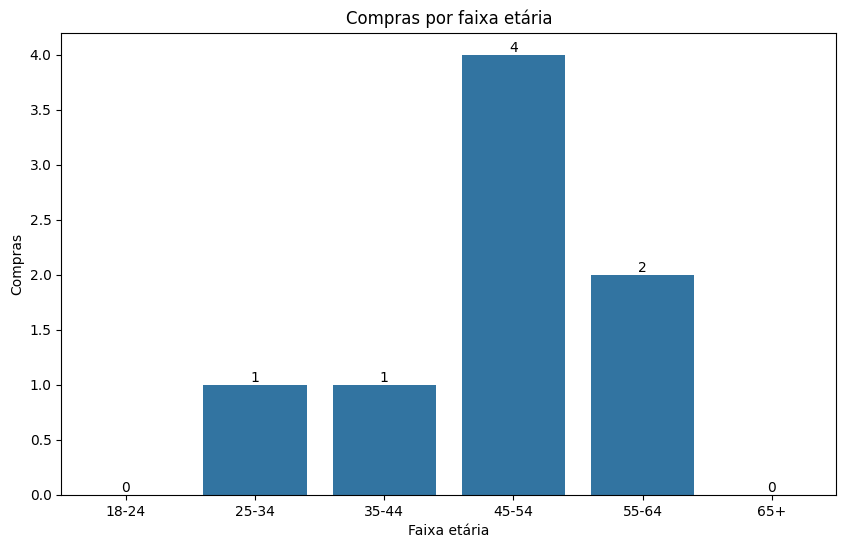

In [247]:
# Criar gráfico de compras por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='Compras'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Compras por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Compras')

plt.show()

### Insight

A faixa etária de **45–54 anos** apresentou o maior número de compras, com **4 compras**, representando **50% das 8 compras registradas** no período.

Em seguida, a faixa de **55–64 anos** registrou **2 compras**, enquanto os grupos de **25–34 anos** e **35–44 anos** realizaram **1 compra cada**.

As faixas de **18–24 anos** e **65+** não registraram compras.

Esse resultado mostra uma diferença importante entre interesse e conversão: embora o grupo de **35–44 anos** tenha liderado em cliques e adições ao carrinho, o público de **45–54 anos** apresentou o maior volume de compras efetivas.

### CTR do link por faixa etária

Além do volume de cliques, também é importante avaliar a eficiência dos anúncios em gerar cliques a partir das impressões recebidas.

Para isso, será analisado o CTR do link, que representa a porcentagem de impressões que resultaram em um clique no link.

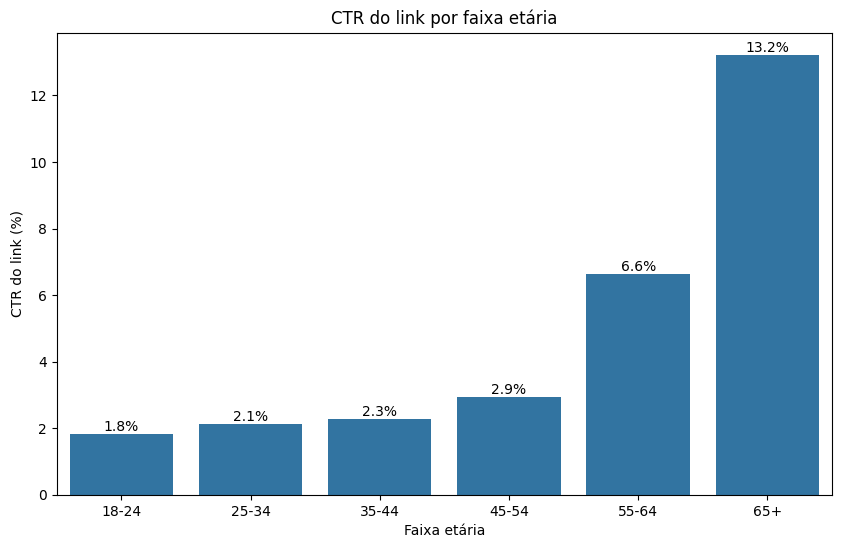

In [248]:
# Criar gráfico do CTR do link por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='CTR do link (%)'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('CTR do link por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('CTR do link (%)')

plt.show()

### Insight

A faixa etária de **65+** apresentou o maior CTR do link, com aproximadamente **13,2%**, seguida pela faixa de **55–64 anos**, com cerca de **6,6%**.

Isso mostra que os anúncios foram especialmente eficientes em gerar cliques entre os públicos mais velhos.

Entretanto, um CTR elevado não significa necessariamente maior conversão em compras. Apesar do forte interesse demonstrado pelo grupo de 65+, nenhuma compra foi registrada nessa faixa etária.

Já o grupo de **45–54 anos**, apesar de apresentar um CTR menor, de aproximadamente **2,9%**, foi responsável pelo maior número de compras.

### Custo por adição ao carrinho por faixa etária

Para complementar a análise de desempenho, será avaliado o custo médio necessário para gerar uma adição ao carrinho em cada faixa etária.

Quanto menor o custo por adição ao carrinho, maior a eficiência do investimento em gerar intenção de compra.

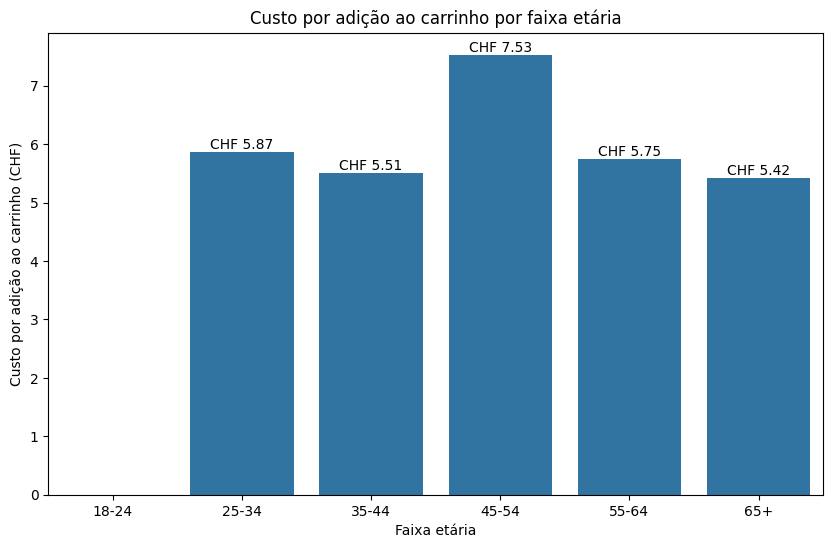

In [249]:
# Criar gráfico do custo por adição ao carrinho por faixa etária

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=idade_df,
    x='Idade',
    y='Custo por adição ao carrinho (CHF)'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='CHF %.2f')

plt.title('Custo por adição ao carrinho por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Custo por adição ao carrinho (CHF)')

plt.show()

### Insight

A faixa etária de **65+** apresentou o menor custo por adição ao carrinho, com aproximadamente **CHF 5,42**, seguida pela faixa de **35–44 anos**, com cerca de **CHF 5,51**.

A faixa de **45–54 anos** apresentou o maior custo por adição ao carrinho, com aproximadamente **CHF 7,53**.

No entanto, o baixo custo observado no grupo de 65+ deve ser interpretado com cautela, pois essa faixa registrou apenas 3 adições ao carrinho e nenhuma compra.

Considerando volume e eficiência em conjunto, a faixa de **35–44 anos** se destaca por combinar o maior número de adições ao carrinho com uma das menores despesas por ação.

### Conclusão da análise por faixa etária

A análise revelou comportamentos diferentes entre as faixas etárias ao longo do funil de conversão.

A faixa de **35–44 anos** apresentou o desempenho mais consistente nas etapas iniciais e intermediárias do funil, liderando em cliques no link, adições ao carrinho e taxa de adição ao carrinho.

Já o grupo de **45–54 anos** se destacou na etapa final, sendo responsável pelo maior número de compras, com 4 das 8 compras registradas.

Os públicos de **55–64 anos** e **65+** apresentaram CTRs elevados, especialmente o grupo de 65+, porém esse interesse em clicar não se traduziu proporcionalmente em compras.

De forma geral, os resultados sugerem que os públicos entre **35 e 54 anos** apresentam maior potencial para a loja, combinando interesse nos anúncios, intenção de compra e conversões efetivas.

<a id="desempenho-anuncios"></a>

# 5. Análise do Desempenho dos Anúncios

Nesta etapa, será analisado o desempenho dos diferentes anúncios presentes nas campanhas.

O objetivo é identificar quais anúncios geraram maior volume de cliques, mais adições ao carrinho e mais compras, além de comparar sua eficiência por meio de métricas como CTR, taxa de adição ao carrinho, custo por adição ao carrinho e custo por compra.

A análise permitirá avaliar quais anúncios apresentaram os melhores resultados ao longo do funil de conversão e quais podem ser priorizados ou otimizados nas próximas campanhas.

In [250]:
# Agrupar as principais métricas por anúncio

anuncios_df = (
    pickhub_df
    .groupby('Nome do anúncio', as_index=False)
    .agg({
        'Impressões': 'sum',
        'Cliques no link': 'sum',
        'Adições ao carrinho': 'sum',
        'Compras': 'sum',
        'Valor gasto (CHF)': 'sum'
    })
)

anuncios_df

,Nome do anúncio,Impressões,Cliques no link,Adições ao carrinho,Compras,Valor gasto (CHF)
0,Arencia | Vídeo 1 | K-Beauty,42,1,0,0,1.22
1,Arencia | Vídeo 2 | Skincare Coreano,1128,11,0,0,17.36
2,Arencia | Vídeo 3 | Rotina K-Beauty,103,0,0,0,1.80
3,Retinal Celimax | Vídeo 1 | Power of Retinal,13969,441,39,7,196.98
4,Retinal Celimax | Vídeo 2 | Dark Spot Care,7713,264,15,1,122.04
5,Retinal Celimax | Vídeo 3 | Skincare Coreano,1674,49,5,0,28.06


In [251]:
# Calcular o CTR do link por anúncio

anuncios_df['CTR do link (%)'] = (
    anuncios_df['Cliques no link'] /
    anuncios_df['Impressões'] * 100
)

# Calcular a taxa de adição ao carrinho por anúncio

anuncios_df['Taxa de adição ao carrinho (%)'] = np.where(
    anuncios_df['Cliques no link'] > 0,
    anuncios_df['Adições ao carrinho'] /
    anuncios_df['Cliques no link'] * 100,
    np.nan
)

# Calcular o CPC do link por anúncio

anuncios_df['CPC do link (CHF)'] = np.where(
    anuncios_df['Cliques no link'] > 0,
    anuncios_df['Valor gasto (CHF)'] /
    anuncios_df['Cliques no link'],
    np.nan
)

# Calcular o custo por adição ao carrinho por anúncio
anuncios_df['Custo por adição ao carrinho (CHF)'] = np.where(
    anuncios_df['Adições ao carrinho'] > 0,
    anuncios_df['Valor gasto (CHF)'] /
    anuncios_df['Adições ao carrinho'],
    np.nan
)

# Calcular o custo por compra por anúncio

anuncios_df['Custo por compra (CHF)'] = np.where(
    anuncios_df['Compras'] > 0,
    anuncios_df['Valor gasto (CHF)'] /
    anuncios_df['Compras'],
    np.nan
)

anuncios_df

,Nome do anúncio,Impressões,Cliques no link,Adições ao carrinho,Compras,Valor gasto (CHF),CTR do link (%),Taxa de adição ao carrinho (%),CPC do link (CHF),Custo por adição ao carrinho (CHF),Custo por compra (CHF)
0,Arencia | Vídeo 1 | K-Beauty,42,1,0,0,1.22,2.380952,0.000000,1.220000,NaN,NaN
1,Arencia | Vídeo 2 | Skincare Coreano,1128,11,0,0,17.36,0.975177,0.000000,1.578182,NaN,NaN
2,Arencia | Vídeo 3 | Rotina K-Beauty,103,0,0,0,1.80,0.000000,NaN,NaN,NaN,NaN
3,Retinal Celimax | Vídeo 1 | Power of Retinal,13969,441,39,7,196.98,3.156990,8.843537,0.446667,5.050769,28.14
4,Retinal Celimax | Vídeo 2 | Dark Spot Care,7713,264,15,1,122.04,3.422793,5.681818,0.462273,8.136000,122.04
5,Retinal Celimax | Vídeo 3 | Skincare Coreano,1674,49,5,0,28.06,2.927121,10.204082,0.572653,5.612000,NaN


### Cliques no link por anúncio

Primeiro, será analisado o volume de cliques no link gerado por cada anúncio.

Essa comparação permite identificar quais criativos foram responsáveis por direcionar maior volume de tráfego para a loja.

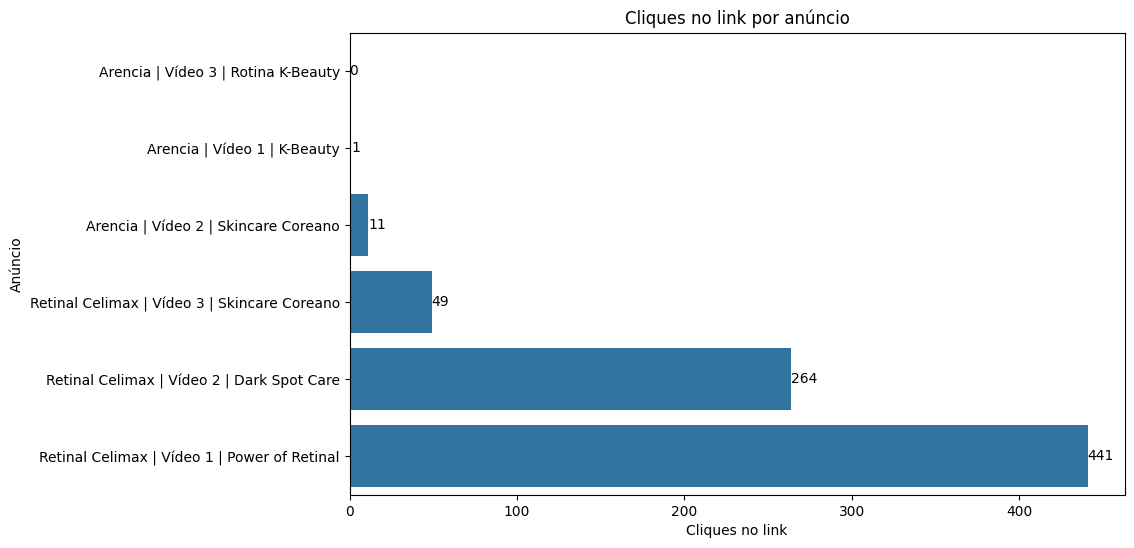

In [252]:
# Ordenar os anúncios pelo número de cliques no link

anuncios_cliques = anuncios_df.sort_values(
    'Cliques no link',
    ascending=True
)

# Criar gráfico de cliques no link por anúncio

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=anuncios_cliques,
    x='Cliques no link',
    y='Nome do anúncio'
)

# Adicionar os valores ao lado das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Cliques no link por anúncio')
plt.xlabel('Cliques no link')
plt.ylabel('Anúncio')

plt.show()

### Insight

O anúncio **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o maior volume de cliques no link, com **441 cliques**.

Em seguida, o **Retinal Celimax | Vídeo 2 | Dark Spot Care** registrou **264 cliques**, enquanto o **Retinal Celimax | Vídeo 3 | Skincare Coreano** teve **49 cliques**.

Os anúncios da linha Arencia tiveram volume de cliques significativamente menor, com no máximo **11 cliques** no período analisado.

Isso indica que os anúncios do produto Retinal Celimax foram responsáveis pela maior parte do tráfego gerado para a loja, com destaque para o vídeo **Power of Retinal**.

### Adições ao carrinho por anúncio

Após analisar o volume de cliques, será avaliado quantas adições ao carrinho foram geradas por cada anúncio.

Essa métrica ajuda a identificar quais criativos conseguiram transformar o interesse inicial em uma intenção de compra mais concreta.

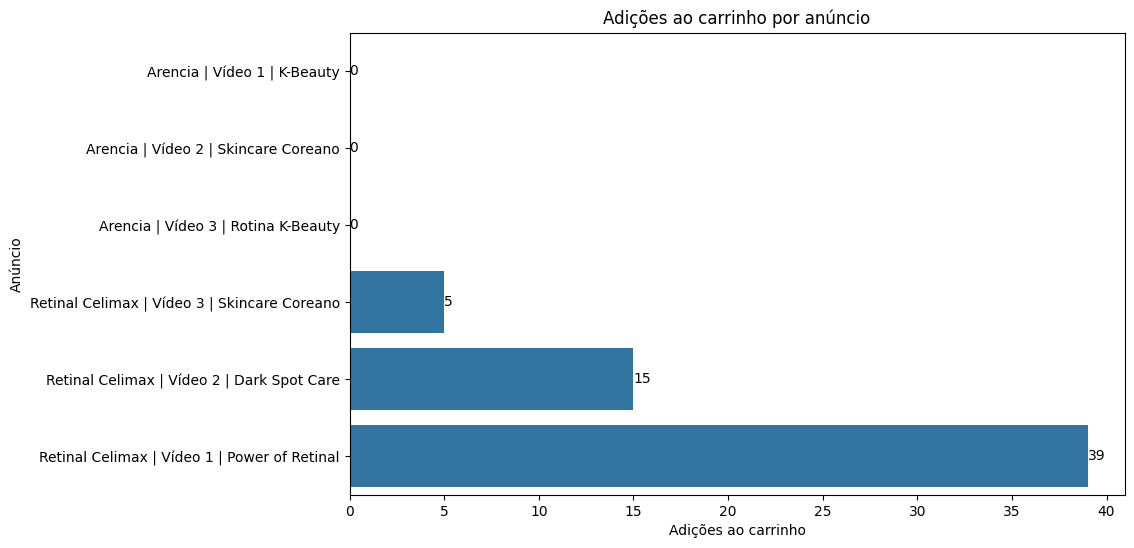

In [253]:
# Ordenar os anúncios pelo número de adições ao carrinho

anuncios_carrinho = anuncios_df.sort_values(
    'Adições ao carrinho',
    ascending=True
)

# Criar gráfico de adições ao carrinho por anúncio

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=anuncios_carrinho,
    x='Adições ao carrinho',
    y='Nome do anúncio'
)

# Adicionar os valores ao lado das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Adições ao carrinho por anúncio')
plt.xlabel('Adições ao carrinho')
plt.ylabel('Anúncio')

plt.show()

### Insight

O anúncio **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o maior número de adições ao carrinho, com **39 eventos**.

Em seguida, o **Retinal Celimax | Vídeo 2 | Dark Spot Care** registrou **15 adições ao carrinho**, enquanto o **Retinal Celimax | Vídeo 3 | Skincare Coreano** gerou **5**.

Os anúncios da linha Arencia não registraram adições ao carrinho no período analisado.

Assim, o vídeo **Power of Retinal** se destacou novamente, apresentando tanto o maior volume de cliques quanto o maior número de adições ao carrinho.

### Taxa de adição ao carrinho por anúncio

Além do número total de adições ao carrinho, será analisada a proporção de cliques no link que resultaram em uma adição ao carrinho.

Essa métrica permite comparar a eficiência dos anúncios em transformar o tráfego gerado em uma intenção de compra.

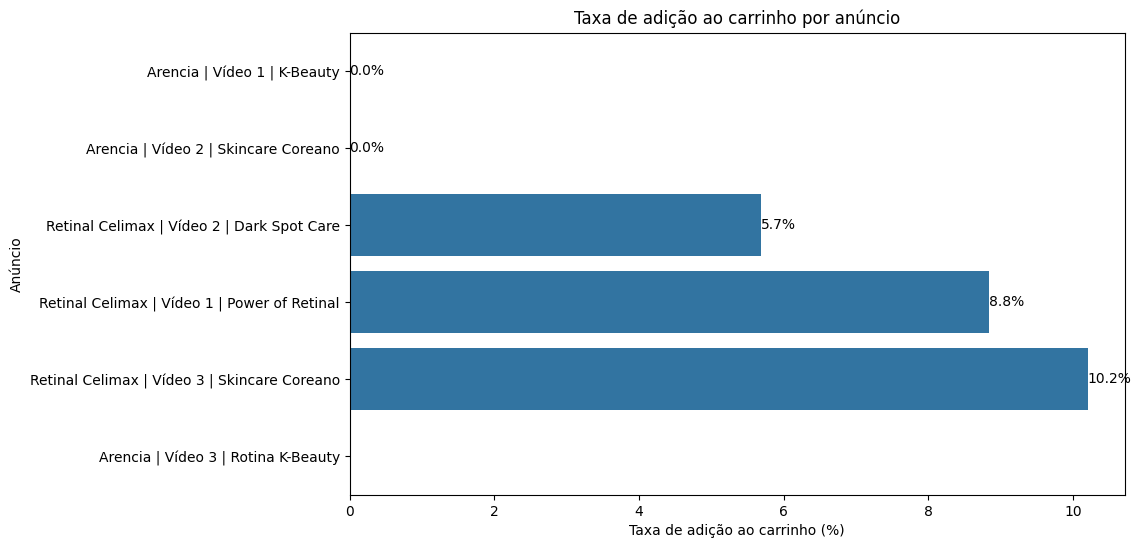

In [254]:
# Ordenar os anúncios pela taxa de adição ao carrinho

anuncios_taxa_carrinho = anuncios_df.sort_values(
    'Taxa de adição ao carrinho (%)',
    ascending=True
)

# Criar gráfico da taxa de adição ao carrinho por anúncio

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=anuncios_taxa_carrinho,
    x='Taxa de adição ao carrinho (%)',
    y='Nome do anúncio'
)

# Adicionar os valores ao lado das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Taxa de adição ao carrinho por anúncio')
plt.xlabel('Taxa de adição ao carrinho (%)')
plt.ylabel('Anúncio')

plt.show()

### Insight

O anúncio **Retinal Celimax | Vídeo 3 | Skincare Coreano** apresentou a maior taxa de adição ao carrinho, com aproximadamente **10,2%** dos cliques resultando em uma adição ao carrinho.

Em seguida, o **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou uma taxa de aproximadamente **8,8%**, enquanto o **Retinal Celimax | Vídeo 2 | Dark Spot Care** registrou cerca de **5,7%**.

Esse resultado mostra uma diferença importante entre volume e eficiência. Embora o vídeo **Power of Retinal** tenha gerado o maior número total de adições ao carrinho, o **Vídeo 3 | Skincare Coreano** apresentou a maior proporção de cliques que avançaram para essa etapa do funil.

No entanto, o Vídeo 3 teve um volume de tráfego consideravelmente menor, com apenas **49 cliques no link**, por isso essa taxa deve ser interpretada em conjunto com o volume de resultados.

### Compras por anúncio

Após analisar os cliques e as adições ao carrinho, o próximo passo é identificar quais anúncios efetivamente geraram compras.

Essa análise permite observar quais criativos conseguiram avançar até a etapa final do funil de conversão.

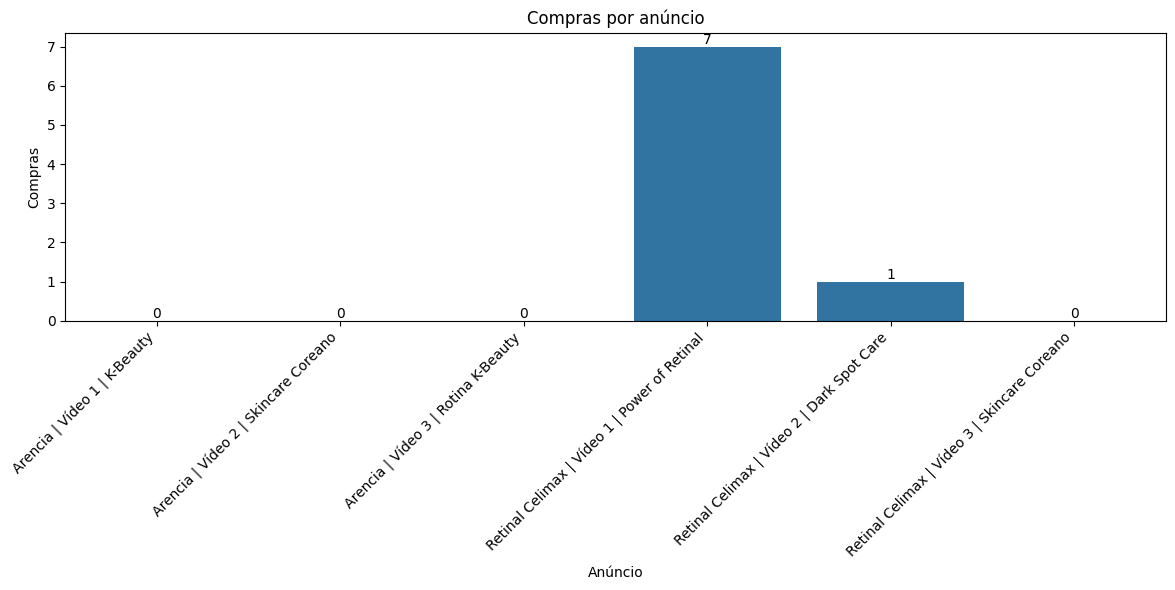

In [255]:
# Criar gráfico de compras por anúncio

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=anuncios_df,
    x='Nome do anúncio',
    y='Compras'
)

# Adicionar os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.title('Compras por anúncio')
plt.xlabel('Anúncio')
plt.ylabel('Compras')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Insight

O anúncio **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o melhor resultado em compras, com **7 compras**, representando **87,5% das 8 compras registradas** no período analisado.

O anúncio **Retinal Celimax | Vídeo 2 | Dark Spot Care** registrou **1 compra**, enquanto os demais anúncios não geraram compras.

Esse resultado mostra que o **Vídeo 1 | Power of Retinal** foi claramente o anúncio mais eficiente em levar os usuários até a etapa final do funil de conversão.

### Custo por compra por anúncio

Além do número total de compras, é importante avaliar quanto foi investido para gerar cada compra.

O custo por compra permite comparar a eficiência financeira dos anúncios na etapa final do funil. Quanto menor o custo por compra, mais eficiente foi o anúncio em transformar o investimento em vendas.

In [256]:
# Exibir o custo por compra de cada anúncio
anuncios_df[
    ['Nome do anúncio', 'Valor gasto (CHF)', 'Compras', 'Custo por compra (CHF)']
]

,Nome do anúncio,Valor gasto (CHF),Compras,Custo por compra (CHF)
0,Arencia | Vídeo 1 | K-Beauty,1.22,0,NaN
1,Arencia | Vídeo 2 | Skincare Coreano,17.36,0,NaN
2,Arencia | Vídeo 3 | Rotina K-Beauty,1.80,0,NaN
3,Retinal Celimax | Vídeo 1 | Power of Retinal,196.98,7,28.14
4,Retinal Celimax | Vídeo 2 | Dark Spot Care,122.04,1,122.04
5,Retinal Celimax | Vídeo 3 | Skincare Coreano,28.06,0,NaN


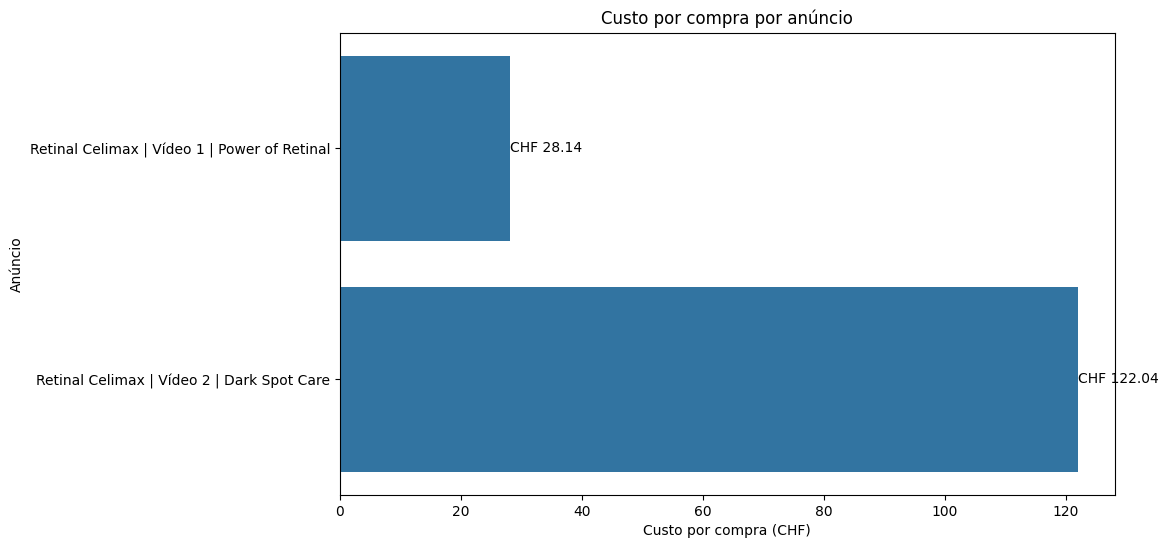

In [257]:
# Filtrar apenas anúncios que geraram compras
anuncios_com_compras = anuncios_df[
    anuncios_df['Compras'] > 0
].copy()

# Criar gráfico do custo por compra
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=anuncios_com_compras,
    x='Custo por compra (CHF)',
    y='Nome do anúncio'
)

for container in ax.containers:
    ax.bar_label(container, fmt='CHF %.2f')

plt.title('Custo por compra por anúncio')
plt.xlabel('Custo por compra (CHF)')
plt.ylabel('Anúncio')

plt.show()

### Conclusão da análise dos anúncios

A análise mostrou que o anúncio **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o desempenho geral mais consistente durante o período analisado.

O anúncio gerou **441 cliques no link**, **39 adições ao carrinho** e **7 das 8 compras registradas**, concentrando aproximadamente **87,5% das compras**. Além do maior volume de conversões, apresentou um **CPC do link de aproximadamente CHF 0,45**, um **custo por adição ao carrinho de CHF 5,05** e um **custo por compra de CHF 28,14**.

O anúncio **Retinal Celimax | Vídeo 2 | Dark Spot Care** apresentou o maior CTR do link, com aproximadamente **3,42%**, indicando boa capacidade de gerar cliques. Entretanto, sua eficiência diminuiu nas etapas seguintes do funil, com taxa de adição ao carrinho de aproximadamente **5,68%** e custo por compra de **CHF 122,04**.

Já o anúncio **Retinal Celimax | Vídeo 3 | Skincare Coreano** apresentou a maior taxa de adição ao carrinho, com aproximadamente **10,2%**. Apesar disso, o resultado foi obtido a partir de um volume menor de tráfego, com **49 cliques e 5 adições ao carrinho**, e nenhuma compra foi registrada.

Os anúncios da linha Arencia apresentaram um volume significativamente menor de impressões e cliques e não registraram adições ao carrinho ou compras. Por esse motivo, seus resultados devem ser interpretados com cautela, principalmente nos anúncios que receberam pouca exposição.

Considerando conjuntamente o volume de tráfego, as conversões e os custos, o **Retinal Celimax | Vídeo 1 | Power of Retinal** se destaca como o anúncio de melhor desempenho no período analisado.

Como foram registradas apenas **8 compras** no total, os resultados relacionados à etapa final do funil devem ser considerados preliminares e acompanhados por um período maior antes de decisões definitivas sobre a distribuição do orçamento.

<a id="principais-resultados"></a>

# 6. Principais Resultados

A partir das análises realizadas, foi possível responder às principais perguntas de negócio definidas para o projeto.

1. **Qual faixa etária mais clicou nos anúncios?**  
   A faixa etária de **35–44 anos** apresentou o maior número de cliques no link, com **228 cliques**.

2. **Qual faixa etária mais adicionou produtos ao carrinho?**  
   O grupo de **35–44 anos** também apresentou o maior número de adições ao carrinho, com **25 eventos**.

3. **Qual faixa etária apresentou a maior taxa de adição ao carrinho?**  
   A faixa de **35–44 anos** apresentou a maior taxa de adição ao carrinho, com aproximadamente **11,0%** dos cliques resultando em uma adição ao carrinho.

4. **Qual anúncio recebeu mais cliques?**  
   O anúncio **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o maior volume de tráfego, com **441 cliques no link**.

5. **Qual anúncio gerou mais adições ao carrinho?**  
   O **Retinal Celimax | Vídeo 1 | Power of Retinal** também liderou nessa etapa, com **39 adições ao carrinho**.

6. **Qual anúncio apresentou a melhor taxa de adição ao carrinho?**  
   O anúncio **Retinal Celimax | Vídeo 3 | Skincare Coreano** apresentou a maior taxa, com aproximadamente **10,2%**. No entanto, esse resultado foi obtido com um volume menor de tráfego, de **49 cliques e 5 adições ao carrinho**.

7. **Qual anúncio apresentou o melhor desempenho geral considerando engajamento, conversões e custos?**  
   O **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o desempenho mais consistente. Além de gerar **441 cliques** e **39 adições ao carrinho**, foi responsável por **7 das 8 compras registradas**, com aproximadamente **87,5% das compras do período**. O anúncio também apresentou **CPC do link de CHF 0,45**, **custo por adição ao carrinho de CHF 5,05** e **custo por compra de CHF 28,14**.

De forma geral, os resultados indicam que o público de **35–44 anos** apresentou o comportamento mais forte nas etapas de interesse e intenção de compra, enquanto a faixa de **45–54 anos** se destacou na conversão final, sendo responsável por **4 das 8 compras registradas**.

Entre os anúncios, o **Power of Retinal** apresentou o conjunto de resultados mais consistente ao longo do funil, combinando alto volume de tráfego, maior número de conversões e custos mais eficientes.

Como o período analisado registrou apenas **8 compras**, os resultados relacionados à etapa final do funil devem ser interpretados como indicativos iniciais.

<a id="recomendacoes"></a>

# 7. Recomendações para a Loja

Com base nos resultados obtidos, algumas ações podem ser consideradas para melhorar a eficiência das próximas campanhas.

- **Priorizar o público entre 35 e 54 anos.**  
  A faixa de **35–44 anos** apresentou o melhor desempenho nas etapas de cliques e adições ao carrinho, enquanto o grupo de **45–54 anos** foi responsável pelo maior número de compras. Esses dois públicos demonstraram o maior potencial ao longo do funil.

- **Manter o público de 55–64 anos em observação.**  
  Essa faixa apresentou um CTR relativamente elevado e registrou **2 compras**, indicando que ainda pode representar uma oportunidade relevante para a loja.

- **Priorizar o anúncio `Retinal Celimax | Vídeo 1 | Power of Retinal`.**  
  Esse anúncio apresentou o desempenho geral mais consistente, liderando em cliques, adições ao carrinho e compras, além de apresentar o menor custo por compra entre os anúncios que geraram conversões. O aumento de investimento nesse criativo pode ser realizado de forma gradual, acompanhando se o desempenho permanece estável.

- **Realizar novos testes com o `Retinal Celimax | Vídeo 3 | Skincare Coreano`.**  
  Apesar de não ter registrado compras, esse anúncio apresentou a maior taxa de adição ao carrinho, com aproximadamente **10,2%**. O resultado sugere um bom potencial de interesse e intenção de compra, mas é necessário um volume maior de dados para avaliar seu desempenho final.

- **Reavaliar o `Retinal Celimax | Vídeo 2 | Dark Spot Care`.**  
  Embora tenha apresentado o maior CTR do link, sua eficiência diminuiu nas etapas seguintes do funil e o custo por compra foi significativamente maior. Novos testes podem avaliar mudanças no criativo, mensagem, oferta ou segmentação.

- **Evitar conclusões definitivas sobre os anúncios da linha Arencia neste momento.**  
  Esses anúncios receberam uma exposição consideravelmente menor do que os anúncios de Retinal Celimax. Apesar de não terem gerado adições ao carrinho ou compras, seria necessário realizar testes com volumes de entrega mais comparáveis antes de concluir que os criativos possuem baixo desempenho.

- **Realizar testes A/B com condições mais semelhantes.**  
  Para comparar criativos de forma mais confiável, as próximas campanhas podem utilizar públicos, períodos e investimentos semelhantes, reduzindo o impacto de diferenças de orçamento e entrega sobre os resultados.

- **Analisar um período maior antes de realizar mudanças significativas de orçamento.**  
  Como apenas **8 compras** foram registradas no período analisado, recomenda-se continuar coletando dados para verificar se os padrões identificados permanecem consistentes.

- **Incluir o valor das compras nos próximos relatórios.**  
  O conjunto de dados utilizado não contém a receita gerada pelas compras. Com essa informação seria possível calcular métricas como **ROAS (Return on Ad Spend)** e avaliar não apenas quais anúncios geram compras, mas também quais geram maior retorno financeiro para a loja.

<a id="conclusao"></a>

# 8. Conclusão

A análise dos dados do Meta Ads permitiu identificar diferenças importantes no comportamento dos públicos e no desempenho dos anúncios ao longo do funil de conversão.

Entre as faixas etárias, o público de **35–44 anos** apresentou o desempenho mais consistente nas etapas de interesse e intenção de compra, liderando em cliques no link, adições ao carrinho e taxa de adição ao carrinho. Já a faixa de **45–54 anos** se destacou na etapa final do funil, sendo responsável por **4 das 8 compras registradas**.

Entre os anúncios, o **Retinal Celimax | Vídeo 1 | Power of Retinal** apresentou o melhor desempenho geral, combinando alto volume de tráfego, maior número de adições ao carrinho e **7 das 8 compras registradas**, além de apresentar o menor custo por compra entre os anúncios que geraram conversões.

Os resultados fornecem informações úteis para orientar novos testes de público, distribuição de orçamento e desenvolvimento de criativos. No entanto, como o período analisado registrou apenas **8 compras** e os anúncios receberam volumes diferentes de exposição, as conclusões relacionadas à conversão final devem ser consideradas preliminares.

Além disso, o conjunto de dados não contém o valor gerado pelas compras. A inclusão dessa informação em análises futuras permitirá calcular o **ROAS** e avaliar de forma mais completa o retorno financeiro das campanhas.